In [1]:
from ncempy.io import dm
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

file = Path("/home/eng-6770/Downloads/Ben_TEM/TEM/TEM,300kV,GL3S5,01Mar2022/ROI middle/UoSEbe5_middle_OA30_295kx_5.tif")

import tifffile
img = tifffile.imread(file)
print(img.shape, img.dtype)

(2048, 2048) uint8


In [37]:
from skimage.util import view_as_windows

def split_patches_and_positions(image, patch_size, stride):
    blocks = view_as_windows(image, window_shape=(patch_size, patch_size), step=stride)
    n_rows, n_cols = blocks.shape[:2]
    patches = blocks.reshape(-1, patch_size, patch_size)
    positions = [(i * stride, j * stride) for i in range(n_rows) for j in range(n_cols)]
    return patches, positions

In [39]:
patched_image, positions = split_patches_and_positions(img, 64, 16)

In [42]:
from scipy import ndimage
from persim import plot_diagrams
from ripser import lower_star_img
from persim import PersistenceImager
import numpy as np

pimgr = PersistenceImager(
    pixel_size=0.02,
    birth_range=(0, 2),
)

def PH_patch(patched_image, scale_percentile=95):
    dgms = []
    for p in patched_image:
        dgm = lower_star_img(p)
        dgm = dgm[np.isfinite(dgm[:, 1])]

        if len(dgm) == 0:
            dgms.append(dgm)
            continue

        births = dgm[:, 0]
        deaths = dgm[:, 1]

        # 1. birth offset normalisation — removes illumination offset
        min_birth = births.min()
        births = births - min_birth
        deaths = deaths - min_birth

        # 2. robust scale normalisation — removes contrast/dynamic-range
        # differences without letting a single outlier dominate
        scale = np.percentile(deaths, scale_percentile)
        if scale <= 0:
            scale = 1.0  # guard against degenerate all-zero diagrams

        births = births / scale
        deaths = deaths / scale

        dgm_norm = np.column_stack([births, deaths])
        dgms.append(dgm_norm)


    vectors = []
    for dgm in dgms:
        pimg = pimgr.transform(dgm)
        vec = pimg.ravel()
        vectors.append(vec)
    vectors = np.vstack(vectors)

    return dgms, vectors

dgms, vectorised_patches = PH_patch(patched_image)


In [43]:
print("positions:", len(positions))
print("vectorised_patches:", len(vectorised_patches) if hasattr(vectorised_patches, '__len__') else vectorised_patches.shape[0])

assert len(positions) == vectorised_patches.shape[0], (
    f"Mismatch: {len(positions)} positions vs {vectorised_patches.shape[0]} vectors"
)

positions: 15625
vectorised_patches: 15625


/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_146498/3331302418.py:17: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


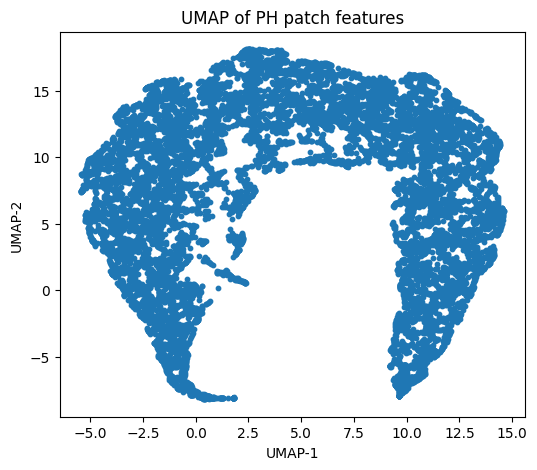

In [44]:
from sklearn.preprocessing import StandardScaler
import umap

X = StandardScaler().fit_transform(vectorised_patches)

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

embedding = reducer.fit_transform(X)

plt.figure(figsize=(6,5))
plt.scatter(
    embedding[:,0],
    embedding[:,1],
    s=10,
    cmap="Spectral"
)
plt.title("UMAP of PH patch features")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

In [45]:
def get_positions(image_data, window_shape, step):
    blocks = view_as_windows(image_data, window_shape, step)
    n_rows, n_cols = blocks.shape[:2]

    positions = [
        (i * step, j * step)
        for i in range(n_rows)
        for j in range(n_cols)
    ]

    return positions

In [40]:
print(len(positions), len(labels))
assert len(positions) == len(labels), "Mismatch — positions and labels are out of sync"

15625 15129


AssertionError: Mismatch — positions and labels are out of sync

In [ ]:
import numpy as np

def label_to_image(original_image, labels, positions, patch_size, stride):

    H, W = original_image.shape[:2]
    unique_labels = np.unique(labels)
    label_to_idx = {lab: i for i, lab in enumerate(unique_labels)}
    n_labels = len(unique_labels)

    # vote_counts[k, r, c] = number of patches voting label k at pixel (r, c)
    vote_counts = np.zeros((n_labels, H, W), dtype=np.int32)

    for (r, c), lab in zip(positions, labels):
        r_end = min(r + patch_size, H)
        c_end = min(c + patch_size, W)rug
        k = label_to_idx[lab]
        vote_counts[k, r:r_end, c:c_end] += 1

    # pixels with no votes at all (gaps, if stride > patch_size) stay as background
    total_votes = vote_counts.sum(axis=0)
    winning_idx = np.argmax(vote_counts, axis=0)

    label_img = np.where(total_votes > 0, unique_labels[winning_idx], 0)

    return label_img

UMAP + GMM

In [47]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=8, covariance_type="full")
labels = gmm.fit_predict(embedding)
positions = get_positions(img, (64,64), 16)
probs = gmm.predict_proba(embedding)

label_img = label_to_image(img, labels, positions, 64, 16)

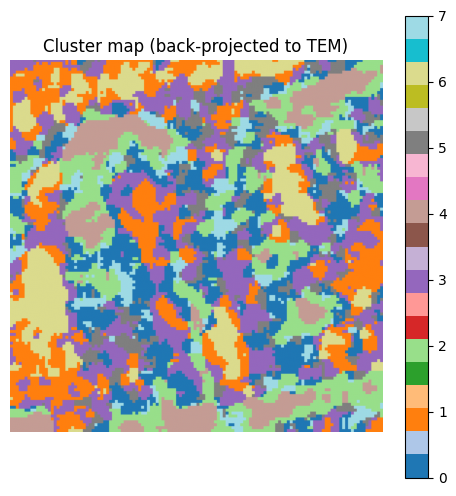

In [48]:
plt.figure(figsize=(6,6))
plt.imshow(label_img, cmap="tab20")
plt.title("Cluster map (back-projected to TEM)")
plt.colorbar()
plt.axis("off")
plt.show()

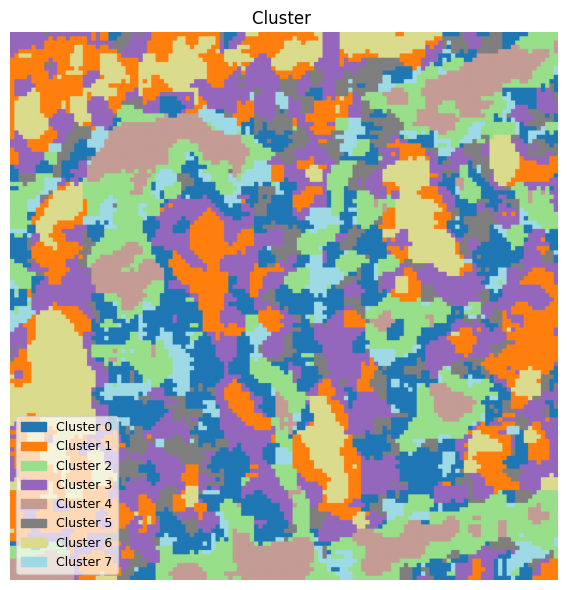

In [49]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

plt.figure(figsize=(6,6))

clusters = np.unique(label_img)
cmap = plt.get_cmap("tab20", len(clusters))

plt.imshow(label_img, cmap=cmap)

plt.title("Cluster ")
plt.axis("off")

legend_patches = [
    mpatches.Patch(color=cmap(i), label=f"Cluster {c}")
    for i, c in enumerate(clusters)
]

plt.legend(
    handles=legend_patches,
    loc="lower left",          # inside plot
    frameon=True,             # box around legend
    framealpha=0.7,           # semi-transparent
    fontsize=9
)

plt.tight_layout()
plt.show()

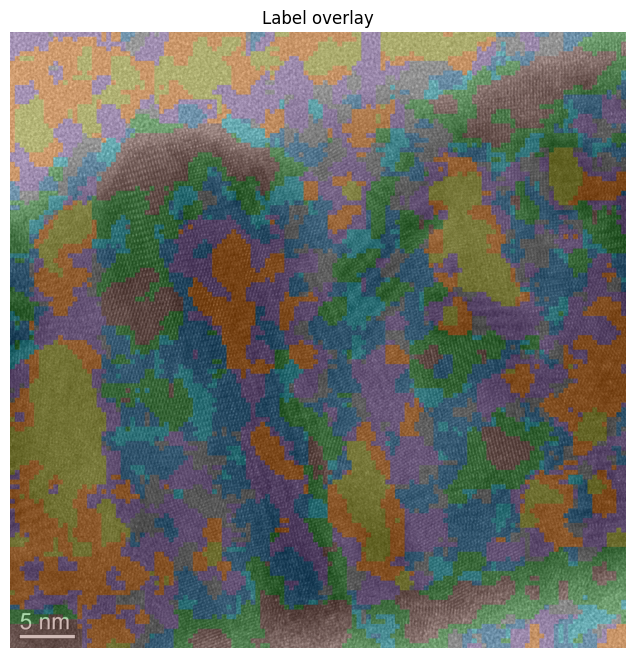

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.imshow(img, cmap="gray")
plt.imshow(label_img, cmap="tab10", alpha=0.4)
plt.axis("off")
plt.title("Label overlay")
plt.show()

In [52]:
patched_image_l, positions_l = split_patches_and_positions(img, 86, 16)

In [53]:
dgms_l, vectorised_patches_l = PH_patch(patched_image_l)

In [54]:
X_l = StandardScaler().fit_transform(vectorised_patches_l)
embedding_l = reducer.fit_transform(X_l)

In [61]:
gmm = GaussianMixture(n_components=8, covariance_type="full")
labels_l = gmm.fit_predict(embedding_l)
positions_l = get_positions(img, (86,86), 16)
probs_l = gmm.predict_proba(embedding_l)

label_img_l = label_to_image(img, labels_l, positions_l, 86, 16)

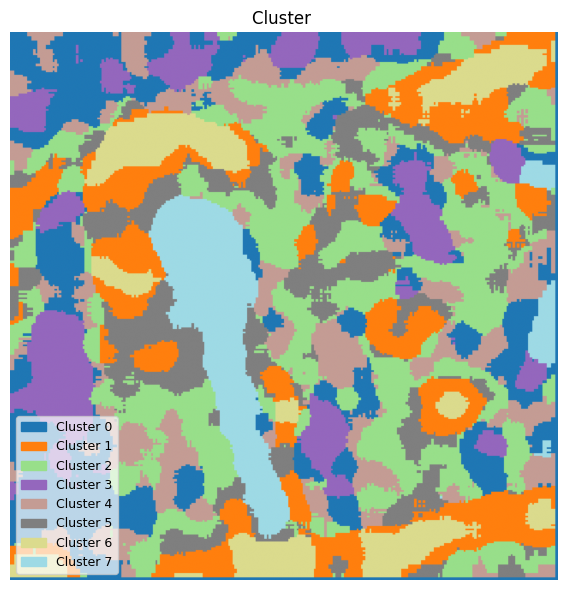

In [63]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

plt.figure(figsize=(6,6))

clusters = np.unique(label_img_l)
cmap = plt.get_cmap("tab20", len(clusters))

plt.imshow(label_img_l, cmap=cmap)

plt.title("Cluster ")
plt.axis("off")

legend_patches = [
    mpatches.Patch(color=cmap(i), label=f"Cluster {c}")
    for i, c in enumerate(clusters)
]

plt.legend(
    handles=legend_patches,
    loc="lower left",          # inside plot
    frameon=True,             # box around legend
    framealpha=0.7,           # semi-transparent
    fontsize=9
)

plt.tight_layout()
plt.show()

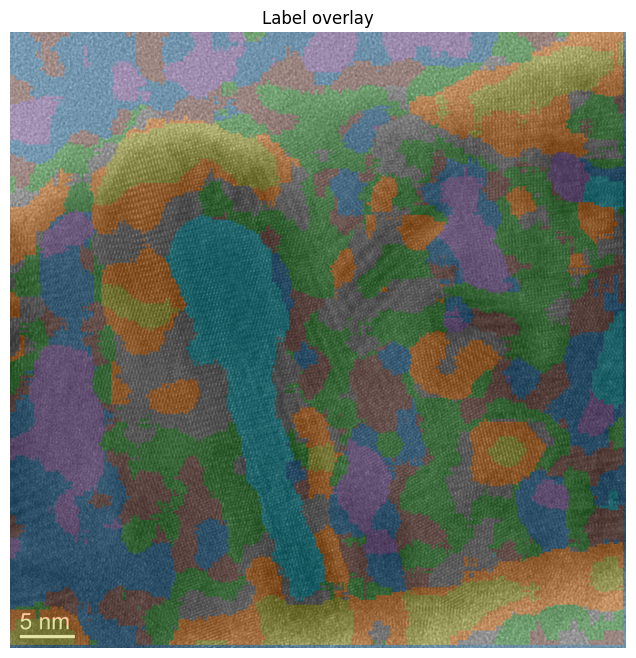

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.imshow(img, cmap="gray")
plt.imshow(label_img_l, cmap="tab10", alpha=0.4)
plt.axis("off")
plt.title("Label overlay")
plt.show()

In [65]:
from scipy.stats import gaussian_kde

def cluster_persistence_density(dgms_in_cluster, grid_size=100, bw_method=None):
    all_points = np.vstack([d for d in dgms_in_cluster if len(d) > 0])
    births = all_points[:, 0]
    lifetimes = all_points[:, 1] - all_points[:, 0]

    coords = np.vstack([births, lifetimes])
    kde = gaussian_kde(coords, bw_method=bw_method)

    # evaluate on a grid for visualisation
    b_min, b_max = births.min(), births.max()
    l_min, l_max = lifetimes.min(), lifetimes.max()

    bb, ll = np.meshgrid(
        np.linspace(b_min, b_max, grid_size),
        np.linspace(l_min, l_max, grid_size)
    )
    grid_coords = np.vstack([bb.ravel(), ll.ravel()])
    density_grid = kde(grid_coords).reshape(grid_size, grid_size)

    return kde, density_grid, (b_min, b_max, l_min, l_max)

In [67]:
cluster_densities = {}
for label in np.unique(labels_l):
    indices = np.where(labels_l == label)[0]
    cluster_dgms = [dgms_l[i] for i in indices]
    kde, density_grid, extent = cluster_persistence_density(cluster_dgms)
    cluster_densities[label] = (density_grid, extent)

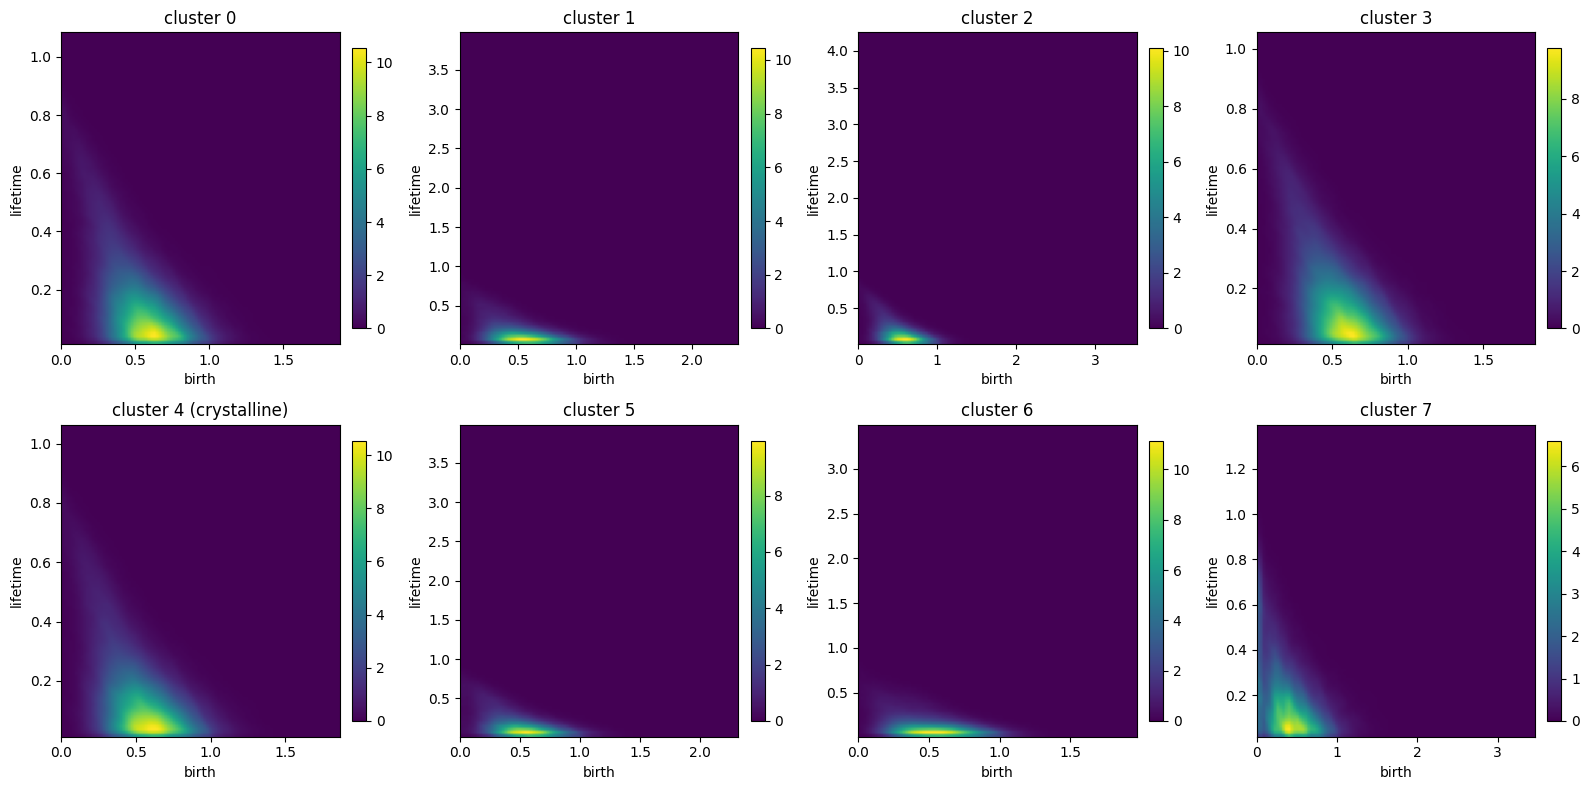

In [68]:
n_clusters = len(cluster_densities)
n_cols = 4
n_rows = int(np.ceil(n_clusters / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, (label, (density_grid, extent)) in zip(axes, cluster_densities.items()):
    im = ax.imshow(density_grid, origin='lower', extent=extent, aspect='auto', cmap='viridis')
    ax.set_title(f"cluster {label}" + (" (crystalline)" if label == 4 else ""))
    ax.set_xlabel("birth")
    ax.set_ylabel("lifetime")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# hide any unused subplot axes
for ax in axes[len(cluster_densities):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

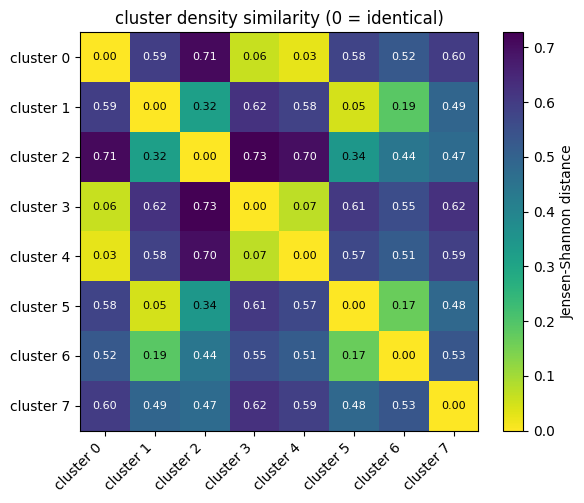

In [69]:
from scipy.spatial.distance import jensenshannon

def normalise_density(density_grid, eps=1e-10):
    flat = density_grid.ravel()
    flat = np.clip(flat, 0, None)
    flat = flat + eps
    return flat / flat.sum()

labels_sorted = sorted(cluster_densities.keys())
n = len(labels_sorted)

similarity_matrix = np.zeros((n, n))

for i, li in enumerate(labels_sorted):
    for j, lj in enumerate(labels_sorted):
        di = normalise_density(cluster_densities[li][0])
        dj = normalise_density(cluster_densities[lj][0])
        similarity_matrix[i, j] = jensenshannon(di, dj)  # 0 = identical, 1 = maximally different

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(similarity_matrix, cmap='viridis_r', vmin=0, vmax=similarity_matrix.max())

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels([f"cluster {l}" for l in labels_sorted], rotation=45, ha='right')
ax.set_yticklabels([f"cluster {l}" for l in labels_sorted])

for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{similarity_matrix[i,j]:.2f}", ha='center', va='center',
                 color='white' if similarity_matrix[i,j] > similarity_matrix.max()/2 else 'black',
                 fontsize=8)

fig.colorbar(im, label="Jensen-Shannon distance")
plt.title("cluster density similarity (0 = identical)")
plt.tight_layout()
plt.show()

1, 5, 6, (2) - transitional/lighter crystalline
0, 3, 4 - more amorphous
7 - heavily crystalline


In [70]:
import numpy as np
import matplotlib.pyplot as plt

def compute_fft_magnitude(patch):
    f = np.fft.fftshift(np.fft.fft2(patch))
    magnitude = np.log(np.abs(f) + 1)  # log scale — makes peaks visible against background
    return magnitude

# 1. Compute FFT magnitude for every patch once, store alongside existing data
fft_magnitudes = np.array([compute_fft_magnitude(p) for p in patched_image_l])  # (n_patches, H, W)
print(fft_magnitudes.shape)

(15129, 86, 86)


In [73]:
cluster_avg_fft = {}
cluster_labels_sorted = sorted(np.unique(labels_l))
for label in cluster_labels_sorted:
    idx = np.where(labels_l == label)[0]
    cluster_avg_fft[label] = fft_magnitudes[idx].mean(axis=0)

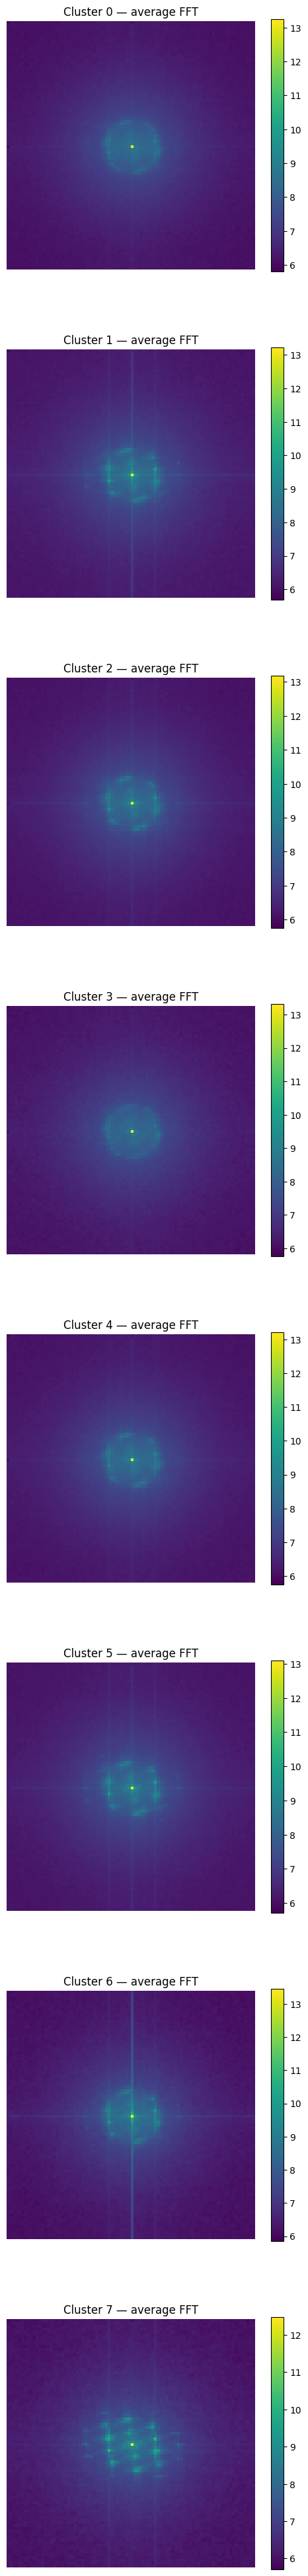

In [76]:
fig, axes = plt.subplots(n, 1, figsize=(5, 5*n))
if n == 1:
    axes = [axes]

for ax, label in zip(axes, cluster_labels_sorted):
    im = ax.imshow(cluster_avg_fft[label])
    ax.set_title(f"Cluster {label} — average FFT")
    ax.axis("off")
    fig.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

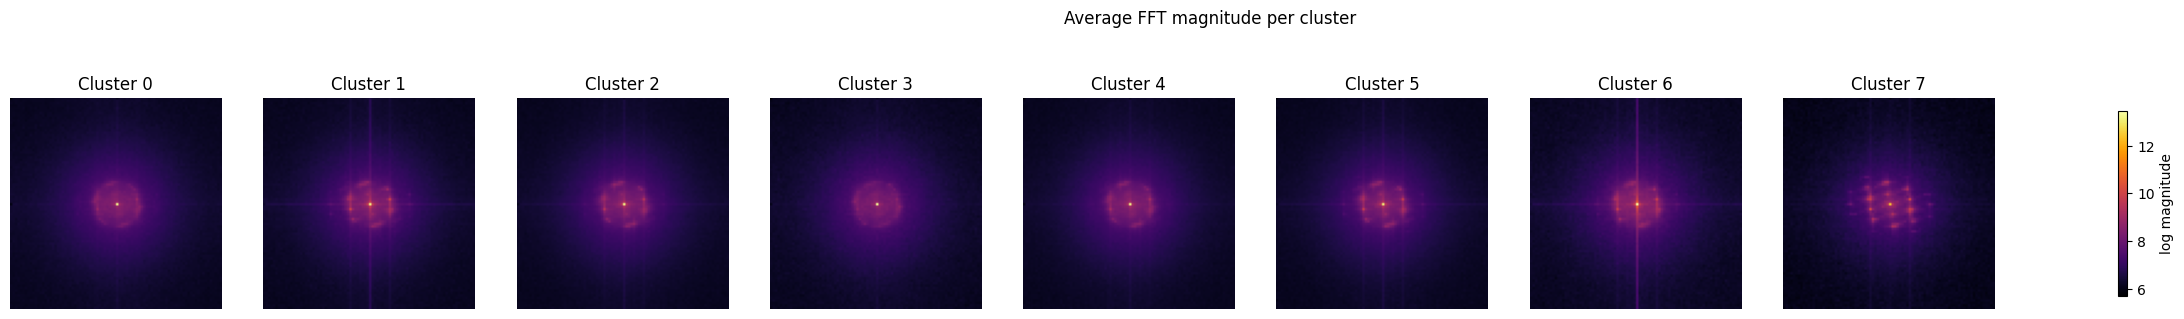

In [75]:
import matplotlib.pyplot as plt

cluster_labels_sorted = sorted(cluster_avg_fft.keys())
n = len(cluster_labels_sorted)

# shared color scale so clusters are visually comparable
vmin = min(cluster_avg_fft[l].min() for l in cluster_labels_sorted)
vmax = max(cluster_avg_fft[l].max() for l in cluster_labels_sorted)

fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
if n == 1:
    axes = [axes]

for ax, label in zip(axes, cluster_labels_sorted):
    im = ax.imshow(cluster_avg_fft[label], cmap="inferno", vmin=vmin, vmax=vmax)
    ax.set_title(f"Cluster {label}")
    ax.axis("off")

fig.colorbar(im, ax=axes, shrink=0.6, label="log magnitude")
plt.suptitle("Average FFT magnitude per cluster")
plt.show()